Found 14129 protein directories


Processing proteins:   0%|          | 0/14129 [00:00<?, ?it/s][09:13:42] Explicit valence for atom # 9 C, 5, is greater than permitted
[09:13:42] sanitize [09:13:42] 1a7x_ligand: [09:13:42] Explicit valence for atom # 9 C, 5, is greater than permitted
[09:13:42] Explicit valence for atom # 53 C, 5, is greater than permitted
Processing proteins:   2%|▏         | 258/14129 [00:00<00:49, 281.04it/s][09:13:43] 1epq_ligand: warning - O.co2 with non C.2 or S.o2 neighbor.
[09:13:43] 1epq_ligand: warning - O.co2 with non C.2 or S.o2 neighbor.
Processing proteins:   3%|▎         | 421/14129 [00:01<00:42, 319.40it/s][09:13:43] Explicit valence for atom # 10 C, 5, is greater than permitted
[09:13:43] sanitize [09:13:43] 1h07_ligand: [09:13:43] Explicit valence for atom # 10 C, 5, is greater than permitted
[09:13:43] Explicit valence for atom # 16 C, 5, is greater than permitted
Processing proteins:   4%|▎         | 516/14129 [00:01<00:50, 270.62it/s][09:13:44] Can't kekulize mol.  Unkekulized ato

Processed 14122 protein-ligand pairs successfully
Results saved to pdbbind_properties.csv

Summary Statistics:
Average QED: 0.4193
Average LogP: -0.2895
Average Molecular Weight: 510.24 g/mol

QED Distribution:
  <0.3: 33.4%
  0.3-0.5: 25.7%
  0.5-0.7: 24.5%
  ≥0.7: 15.9%
Visualizations saved to pdbbind_analysis


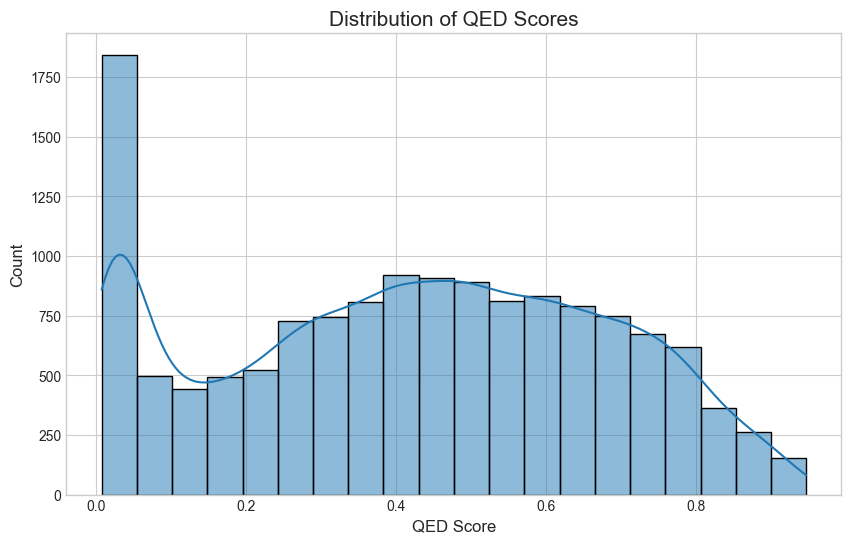

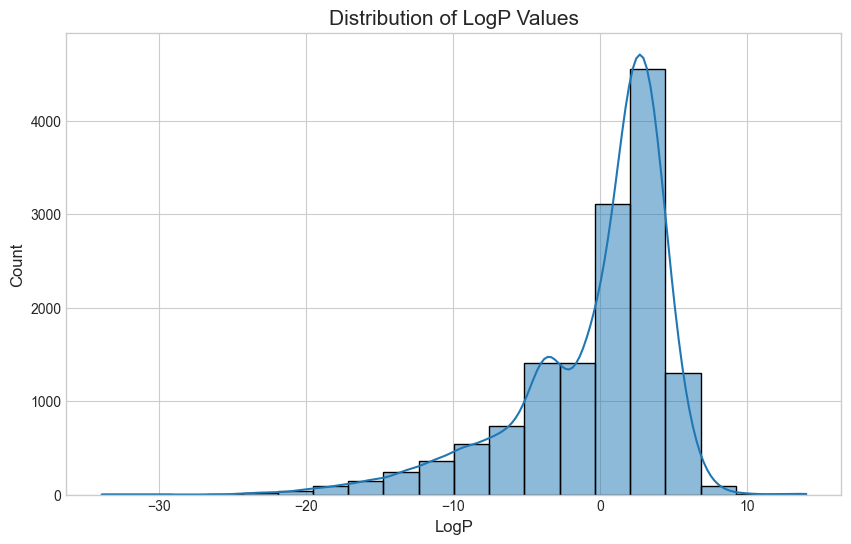

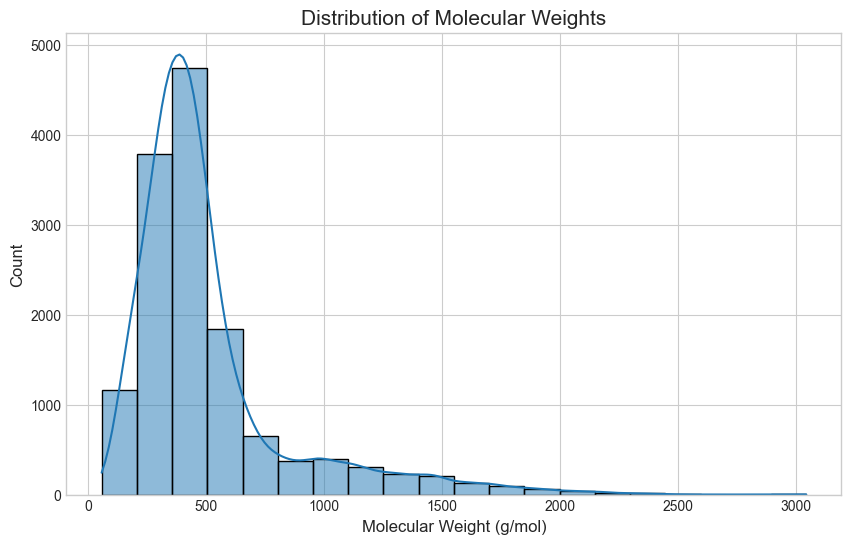

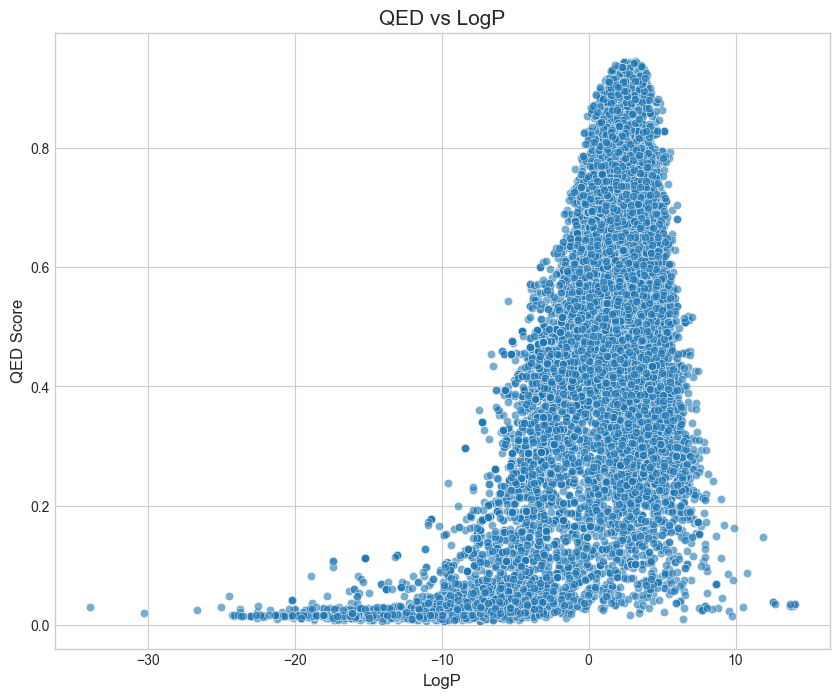

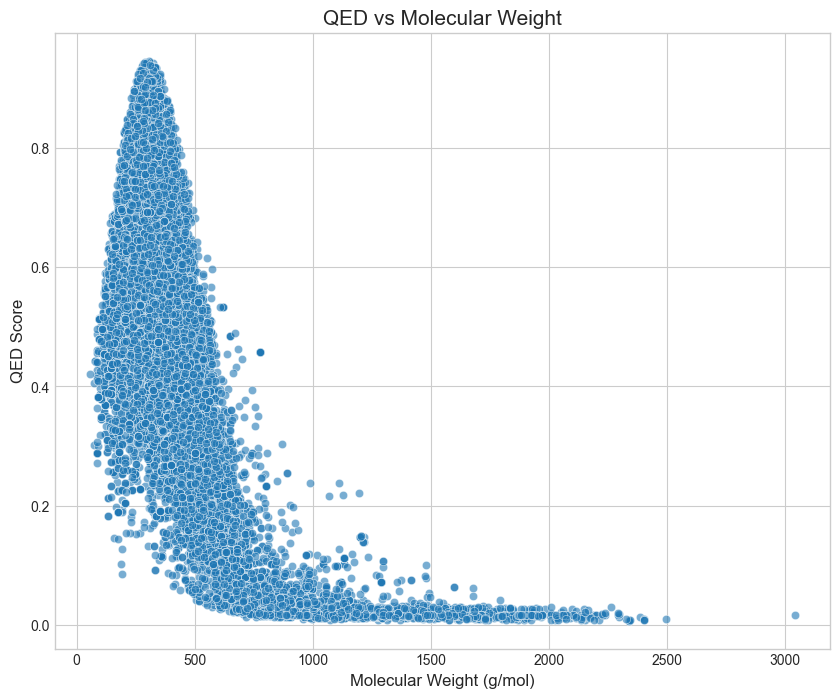

In [2]:
import os
import csv
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, QED, Descriptors
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

def mol2_to_smiles(mol2_file):
    """Convert a mol2 file to SMILES string using RDKit"""
    try:
        mol = Chem.MolFromMol2File(mol2_file, sanitize=True)
        if mol is None:
            # Try again without sanitization
            mol = Chem.MolFromMol2File(mol2_file, sanitize=False)
            if mol is None:
                return None
            # Now try to sanitize
            try:
                Chem.SanitizeMol(mol)
            except:
                pass  # Continue even if sanitization fails
        
        smiles = Chem.MolToSmiles(mol)
        return smiles
    except Exception as e:
        print(f"Error processing {mol2_file}: {str(e)}")
        return None

def calculate_properties(smiles):
    """Calculate molecular properties for a SMILES string"""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None, None, None
        
        qed = QED.qed(mol)
        logp = Descriptors.MolLogP(mol)
        mw = Descriptors.MolWt(mol)
        
        return qed, logp, mw
    except:
        return None, None, None

def process_pdbbind_dataset(base_dir, output_file='pdbbind_properties.csv'):
    """
    Process the PDBbind dataset to extract ligand properties.
    
    Args:
        base_dir: Base directory containing PDBbind protein folders
        output_file: Path to save the output CSV file
    """
    results = []
    
    # Get list of all protein folders
    protein_dirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
    print(f"Found {len(protein_dirs)} protein directories")
    
    for protein_dir in tqdm(protein_dirs, desc="Processing proteins"):
        protein_path = os.path.join(base_dir, protein_dir)
        
        # Find ligand mol2 file
        ligand_files = [f for f in os.listdir(protein_path) if f.endswith('_ligand.mol2')]
        if not ligand_files:
            continue
        
        ligand_file = os.path.join(protein_path, ligand_files[0])
        
        # Convert mol2 to SMILES
        smiles = mol2_to_smiles(ligand_file)
        if smiles is None:
            continue
        
        # Calculate properties
        qed, logp, mw = calculate_properties(smiles)
        
        # Add to results
        results.append({
            'pdb_id': protein_dir,
            'smiles': smiles,
            'qed': qed,
            'logp': logp,
            'molecular_weight': mw
        })
    
    # Convert to DataFrame and save
    df = pd.DataFrame(results)
    df.to_csv(output_file, index=False)
    
    print(f"Processed {len(df)} protein-ligand pairs successfully")
    print(f"Results saved to {output_file}")
    
    # Calculate and display summary statistics
    print("\nSummary Statistics:")
    print(f"Average QED: {df['qed'].mean():.4f}")
    print(f"Average LogP: {df['logp'].mean():.4f}")
    print(f"Average Molecular Weight: {df['molecular_weight'].mean():.2f} g/mol")
    
    # QED distribution
    qed_ranges = {
        '<0.3': (df['qed'] < 0.3).mean() * 100,
        '0.3-0.5': ((df['qed'] >= 0.3) & (df['qed'] < 0.5)).mean() * 100,
        '0.5-0.7': ((df['qed'] >= 0.5) & (df['qed'] < 0.7)).mean() * 100,
        '≥0.7': (df['qed'] >= 0.7).mean() * 100
    }
    
    print("\nQED Distribution:")
    for range_name, percentage in qed_ranges.items():
        print(f"  {range_name}: {percentage:.1f}%")
    
    return df

# Data visualization functions
def create_visualizations(df, output_dir='pdbbind_analysis'):
    """Create visualizations for the dataset"""
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    os.makedirs(output_dir, exist_ok=True)
    
    # Set style
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # 1. QED Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(df['qed'], bins=20, kde=True)
    plt.title('Distribution of QED Scores', fontsize=15)
    plt.xlabel('QED Score', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.savefig(os.path.join(output_dir, 'qed_distribution.png'), dpi=300, bbox_inches='tight')
    
    # 2. LogP Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(df['logp'], bins=20, kde=True)
    plt.title('Distribution of LogP Values', fontsize=15)
    plt.xlabel('LogP', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.savefig(os.path.join(output_dir, 'logp_distribution.png'), dpi=300, bbox_inches='tight')
    
    # 3. Molecular Weight Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(df['molecular_weight'], bins=20, kde=True)
    plt.title('Distribution of Molecular Weights', fontsize=15)
    plt.xlabel('Molecular Weight (g/mol)', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.savefig(os.path.join(output_dir, 'mw_distribution.png'), dpi=300, bbox_inches='tight')
    
    # 4. QED vs LogP Scatter Plot
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x='logp', y='qed', data=df, alpha=0.6)
    plt.title('QED vs LogP', fontsize=15)
    plt.xlabel('LogP', fontsize=12)
    plt.ylabel('QED Score', fontsize=12)
    plt.savefig(os.path.join(output_dir, 'qed_vs_logp.png'), dpi=300, bbox_inches='tight')
    
    # 5. QED vs Molecular Weight
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x='molecular_weight', y='qed', data=df, alpha=0.6)
    plt.title('QED vs Molecular Weight', fontsize=15)
    plt.xlabel('Molecular Weight (g/mol)', fontsize=12)
    plt.ylabel('QED Score', fontsize=12)
    plt.savefig(os.path.join(output_dir, 'qed_vs_mw.png'), dpi=300, bbox_inches='tight')
    
    print(f"Visualizations saved to {output_dir}")

if __name__ == '__main__':
    # Path to PDBbind dataset
    pdbbind_dir = r"C:\Users\kani1\Downloads\PDBbind_v2020_other_PL\v2020-other-PL"
    
    # Process the dataset
    df = process_pdbbind_dataset(pdbbind_dir, output_file='pdbbind_properties.csv')
    
    try:
        # Create visualizations if matplotlib and seaborn are available
        create_visualizations(df)
    except ImportError:
        print("Matplotlib or seaborn not available. Skipping visualizations.")